In [ ]:
!pip install numpy
!pip install matplotlib
!pip install scipy
!pip install OpenCv

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy as sci
import cv2

In [3]:
#Takes a horizontal row and returns the pixel values to curve fit
def horizontalPointSweep(image, sweepRow=-1):


    #Take pixel values from startingWidth to end of image
    pixelValues = image[sweepRow, -100:]
    widthArray = range(len(pixelValues))

    return widthArray, pixelValues

In [ ]:
#Used for creating cosine curve of best fit
def cosineModel(x, a, b, c, d):
    
    return a*(np.cos(b*x+c)) + d

In [ ]:
#Used for creating a line of best fit
def lineModel(x, m, b):
    return (m*x) + b

In [5]:
#To find b0, take FFT and find the most dominant peak frequency

def frequencyGuess(data):
    


    #Calculate FFT of dataset
    fft_values = np.fft.fft(data)
    amplitude = np.abs(fft_values)

    #Obtain frequncy of data. Sampling period is one since our sampling period is a pixel
    freqs = np.fft.fftfreq(len(data), 1)

    # Only use positive frequencies
    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    amp_pos = amplitude[pos_mask]

    # Dominant frequency = frequency with highest magnitude
    peak_freq = freqs_pos[np.argmax(amp_pos)]

    #Convert Hz to rad/s (or I gues rad/pixel in this case)
    return peak_freq * 2 * np.pi

In [6]:
#Function to determine how many frames to skip to get to next frame of interest
def framesToSkip(FPS, previousFTSValue, tBP):


    FPS = int(FPS)
    
    #For the first opened frame
    if(previousFTSValue == -1):
        return 0

    #Done since if FPS is not cleanly divisible by time interval between patterns, eventually
    #The nextFrame value will stay within the current frame
    if(FPS % 2 == 1):
        if(previousFTSValue == int(.5 * FPS)):
            nextFrame = int(tBP * FPS) + 1
        else:
            nextFrame = int(tBP * FPS)

    else:
        nextFrame = int(tBP * FPS)


    return nextFrame


In [ ]:
#Used to fit a cosine curve to video file data. Returns coefficients
#f(x) = A*cos(B*x + C) + D
def fitCurve(x_data, y_data, a0 = -1, b0 = -1, c0 = -1, d0 = -1):

    #Initial Guesses if not specified in function call
    if(a0 == -1):
        a0 = np.max(y_data) - np.min(y_data)
    
    if(b0 == -1):
        b0 = frequencyGuess(y_data)

    if(c0 == -1):
        c0 = 0
    
    if(d0 == -1):
        d0 = np.average(y_data)


    popt, pcov = sci.optimize.curve_fit(cosineModel, x_data, y_data, p0 = [a0, b0, c0, d0])

    return popt


    

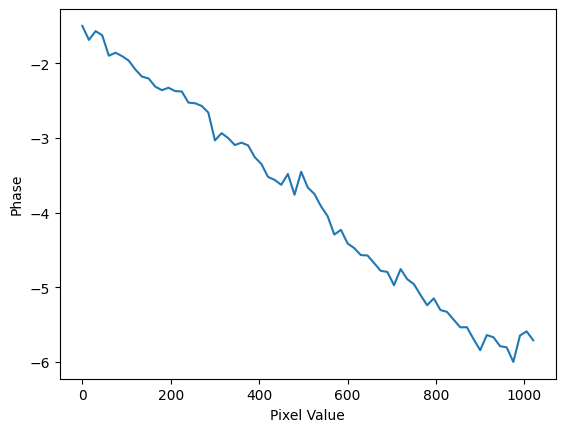

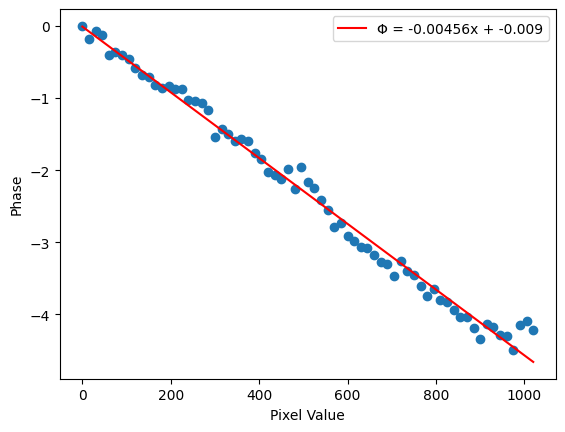

In [ ]:
#Open video into python
#-------------------------------------------------------------------------------------------------
#TODO - UPDATE WITH YOUR PATH TO THE VIDEO FILE
video_path = "fringes (p3 -400) 2s_2025-11-21-175831-0000.avi"
#-------------------------------------------------------------------------------------------------


cap = cv2.VideoCapture(video_path)

#Used for determining the amount of frames to skip for given frame rate
FPS = cap.get(cv2.CAP_PROP_FPS)
skippedFrames = -1


#-------------------------------------------------------------------------------------------------
#TODO - INPUT YOUR TIME EACH PATTERN IS DISPLAYED FOR HERE (IN SECONDS)
timeBetweenPatterns = 1 #seconds
#-------------------------------------------------------------------------------------------------

#Storing phases
phases = []
frameCount = 0

#Initial c0 value
c0 = 0

#Amount of generated patterns contained in video

#-------------------------------------------------------------------------------------------------
#TODO - IF THE NUMBER OF PATTERNS WAS CHANGED IN PATTERN GENERATION SCRIPT, UPDATE HERE AS WELL
numOfPatterns = 69
#-------------------------------------------------------------------------------------------------


totalFrames = cap.get(cv2.CAP_PROP_FRAME_COUNT)

#Create Array of pattern pixel values for plotting
pixelValues = np.linspace(0,1020, numOfPatterns)




#Array for creating video
videoFrames = []

#Determining where to start the analysis
previousC = -1
firstPatternFound = False
while(cap.isOpened() and not firstPatternFound):

    #Open a frame
    success, img = cap.read()
    frameCount += 1

    #Breaks if frame not properly opened
    if success:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    else:
        break

    #Collect data to analyze
    x_data, y_data = horizontalPointSweep(img, 200)

    #Fit the curve - only pass c0 guess
    A,B,C,D = fitCurve(x_data, y_data, c0 = c0)
    
    #Skips iteration for the first frame
    if(previousC == -1):
        previousC = C
        continue

    #Point found to start analysis
    elif((previousC - C) > 1):
        firstPatternFound = True

        #Skip 5 frames ahead to level out data. Number chosen by TLAR method
        for i in range(10):
            cap.read()
            frameCount += 1





#Loop to iterate through patterns and evaluate the phase change
for pattern in range(numOfPatterns):


    #Determine the amount of frames needed to skip to get to next pattern image
    skippedFrames = framesToSkip(FPS, skippedFrames, timeBetweenPatterns)

    #To skip the amount of frames equal to the amount of time it takes for the pattern to switch
    for i in range(skippedFrames):
        cap.read()
        frameCount += 1

    #Open a frame
    success, img = cap.read()
    frameCount += 1

    #Breaks if frame not properly opened
    if success:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    else:
        break


    

    #Pull data from frame to analyze
    x_data, y_data = horizontalPointSweep(img, 200)

    A,B,C,D = fitCurve(x_data, y_data, -1,-1, -1,-1)

    c0 = C


    #To correct for wrapping. Conditional is to make sure loop doesn't execute first pattern iteration

    if(len(phases) > 0):

        while((C - phases[-1]) > 2):

            C = C - (np.pi)

        while((C - phases[-1]) < -2):

            C = C + (np.pi)

    phases.append(C)

    print(f"Percent Done {int(10000 * (frameCount/totalFrames))/100}%", end="\r")

    videoFrames.append(img)

    # plt.figure()
    # plt.scatter(x_data[:100], y_data[:100])
    # plt.plot(x_data, model(x_data,A,B,C,D))


#Normalize phases to the first pattern at 0 rad

norm_phases = phases - phases[0]
test = np.unwrap(norm_phases)


#Create line of best fit to the data
coefficients, covarianceMatrix = sci.optimize.curve_fit(lineModel, pixelValues, norm_phases)
m, b = coefficients
lineEquation = f"Φ = {format(m, '.5f')}x + {format(b, '.3f')}"



plt.figure()
# plt.scatter(pixelValues, test)
plt.scatter(pixelValues, norm_phases)
plt.plot(pixelValues, lineModel(pixelValues,m, b), label = lineEquation, color = "red")
plt.ylabel("Phase")
plt.xlabel("Pixel Value")
plt.legend()



    